# Physics-Informed Soil-Moisture Forecasting

The previous modelling stages established two important findings.

First, a simple soil-water balance model using rainfall and irrigation could not fully explain short-term changes in measured soil moisture.

Second, persistence was a very strong one-hour forecasting baseline, while a residual LSTM became more useful during meaningful changes, particularly during drying events.

The purpose of this notebook is to investigate whether physical information from the soil-water balance can improve data-driven forecasting.

Rather than replacing the neural network with a physical model, this stage will investigate how the physical water-balance signal can be incorporated into the learning process.

The main target remains one-hour-ahead Port1 soil moisture.

The experiments will be evaluated chronologically, with training and validation data used for model development and the later test period reserved for final evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

data_file = Path("../data/processed/irrigation_model_data.csv")

data = pd.read_csv(
    data_file,
    parse_dates=["Timestamps"]
)

data = data.sort_values("Timestamps").reset_index(drop=True)

print("Rows:", len(data))
print("Columns:", len(data.columns))
print("Start:", data["Timestamps"].min())
print("End:", data["Timestamps"].max())

data.head()

Rows: 11770
Columns: 10
Start: 2022-08-01 00:15:00
End: 2023-02-28 23:45:00


,Timestamps,Port1,Port2,Port3,Port4,Port5,Port6,Rainfall,Irrigation,Temperature
0,2022-08-01 00:15:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,27.0
1,2022-08-01 00:30:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.9
2,2022-08-01 00:45:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.8
3,2022-08-01 01:00:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.8
4,2022-08-01 01:15:00,0.257,0.133,0.172,0.204,0.2,0.155,0.0,0.0,26.8


In [2]:
# Check whether timestamps are unique before creating the target

duplicate_count = data["Timestamps"].duplicated().sum()
unique_duplicate_timestamps = data.loc[
    data["Timestamps"].duplicated(keep=False),
    "Timestamps"
].nunique()

print("Rows with duplicated timestamps:", duplicate_count)
print(
    "Unique duplicated timestamps:",
    unique_duplicate_timestamps
)

Rows with duplicated timestamps: 4
Unique duplicated timestamps: 4


In [32]:
duplicates = data[
    data["Timestamps"].duplicated(keep=False)
].sort_values("Timestamps")

print(duplicates[
    [
        "Timestamps",
        "Port1",
        "Port2",
        "Port3",
        "Port4",
        "Port5",
        "Port6",
        "Rainfall",
        "Irrigation",
        "Temperature"
    ]
].to_string(index=False))

         Timestamps  Port1  Port2  Port3  Port4  Port5  Port6  Rainfall  Irrigation  Temperature
2022-10-30 04:30:00  0.233  0.185  0.177  0.206  0.209  0.226       0.0         0.0         17.4
2022-10-30 04:30:00  0.233  0.185  0.177  0.206  0.209  0.226       0.0         0.0         17.4
2022-10-30 04:45:00  0.233  0.185  0.177  0.206  0.209  0.226       0.0         0.0         17.4
2022-10-30 04:45:00  0.233  0.185  0.177  0.206  0.209  0.226       0.0         0.0         17.4
2022-10-30 05:00:00  0.233  0.185  0.177  0.206  0.209  0.226       0.0         0.0         17.4
2022-10-30 05:00:00  0.233  0.185  0.177  0.206  0.209  0.226       0.0         0.0         17.4
2022-10-30 05:15:00  0.233  0.185  0.177  0.206  0.209  0.226       0.0         0.0         17.4
2022-10-30 05:15:00  0.233  0.185  0.177  0.206  0.209  0.226       0.0         0.0         17.4


In [3]:
# Remove exact duplicate records
before = len(data)

data = data.drop_duplicates().copy()

after = len(data)

print("Rows before removing exact duplicates:", before)
print("Rows after removing exact duplicates:", after)
print("Rows removed:", before - after)

print(
    "Duplicated timestamps remaining:",
    data["Timestamps"].duplicated().sum()
)

Rows before removing exact duplicates: 11770
Rows after removing exact duplicates: 11766
Rows removed: 4
Duplicated timestamps remaining: 0


In [17]:
# Create the one-hour-ahead forecasting target

data["Target_time"] = (
    data["Timestamps"] + pd.Timedelta(hours=1)
)

port1_lookup = (
    data.set_index("Timestamps")["Port1"]
)

data["Port1_1h_future"] = (
    data["Target_time"].map(port1_lookup)
)

data["delta_theta_1h"] = (
    data["Port1_1h_future"] - data["Port1"]
)

valid_target = data["Port1_1h_future"].notna()

forecast_data = (
    data.loc[valid_target]
    .copy()
    .reset_index(drop=True)
)

print("Total rows:", len(data))
print("Rows with valid 1-hour target:", len(forecast_data))
print(
    "Rows without valid 1-hour target:",
    (~valid_target).sum()
)

print(
    "\nMean 1-hour change:",
    forecast_data["delta_theta_1h"].mean()
)

print(
    "Minimum 1-hour change:",
    forecast_data["delta_theta_1h"].min()
)

print(
    "Maximum 1-hour change:",
    forecast_data["delta_theta_1h"].max()
)

forecast_data[
    [
        "Timestamps",
        "Port1",
        "Target_time",
        "Port1_1h_future",
        "delta_theta_1h"
    ]
].head(10)

Total rows: 11766
Rows with valid 1-hour target: 11449
Rows without valid 1-hour target: 317

Mean 1-hour change: 3.930474277229436e-06
Minimum 1-hour change: -0.01100000000000001
Maximum 1-hour change: 0.167


,Timestamps,Port1,Target_time,Port1_1h_future,delta_theta_1h
0,2022-08-01 00:15:00,0.257,2022-08-01 01:15:00,0.257,0.000
1,2022-08-01 00:30:00,0.257,2022-08-01 01:30:00,0.256,-0.001
2,2022-08-01 00:45:00,0.257,2022-08-01 01:45:00,0.256,-0.001
3,2022-08-01 01:00:00,0.257,2022-08-01 02:00:00,0.256,-0.001
4,2022-08-01 01:15:00,0.257,2022-08-01 02:15:00,0.255,-0.002
5,2022-08-01 01:30:00,0.256,2022-08-01 02:30:00,0.255,-0.001
6,2022-08-01 01:45:00,0.256,2022-08-01 02:45:00,0.255,-0.001
7,2022-08-01 02:00:00,0.256,2022-08-01 03:00:00,0.255,-0.001
8,2022-08-01 02:15:00,0.255,2022-08-01 03:15:00,0.255,0.000
9,2022-08-01 02:30:00,0.255,2022-08-01 03:30:00,0.254,-0.001


In [18]:
# Check the actual time difference between each observation
# and its one-hour target.

forecast_data["actual_target_gap"] = (
    forecast_data["Target_time"]
    - forecast_data["Timestamps"]
).dt.total_seconds() / 3600

print(
    "Target gap values:",
    forecast_data["actual_target_gap"].value_counts().sort_index()
)

print(
    "\nRows with exactly 1-hour target:",
    (forecast_data["actual_target_gap"] == 1.0).sum()
)

print(
    "Rows with incorrect target gap:",
    (forecast_data["actual_target_gap"] != 1.0).sum()
)

Target gap values: actual_target_gap
1.0    11449
Name: count, dtype: int64

Rows with exactly 1-hour target: 11449
Rows with incorrect target gap: 0


In [36]:
# Build previous-one-hour water input features

forecast_data = forecast_data.sort_values(
    "Timestamps"
).reset_index(drop=True)

forecast_data["Rainfall_prev_1h"] = (
    forecast_data["Rainfall"]
    .shift(1)
    .rolling(window=4, min_periods=4)
    .sum()
)

forecast_data["Irrigation_prev_1h"] = (
    forecast_data["Irrigation"]
    .shift(1)
    .rolling(window=4, min_periods=4)
    .sum()
)

print(
    "Rainfall previous 1h mean:",
    forecast_data["Rainfall_prev_1h"].mean()
)

print(
    "Rainfall previous 1h maximum:",
    forecast_data["Rainfall_prev_1h"].max()
)

print(
    "Irrigation previous 1h mean:",
    forecast_data["Irrigation_prev_1h"].mean()
)

print(
    "Irrigation previous 1h maximum:",
    forecast_data["Irrigation_prev_1h"].max()
)

print(
    "\nRows with complete previous-hour inputs:",
    forecast_data[
        [
            "Rainfall_prev_1h",
            "Irrigation_prev_1h"
        ]
    ].notna().all(axis=1).sum()
)

forecast_data[
    [
        "Timestamps",
        "Rainfall",
        "Irrigation",
        "Rainfall_prev_1h",
        "Irrigation_prev_1h",
        "delta_theta_1h"
    ]
].head(10)

Rainfall previous 1h mean: 0.04036697247706422
Rainfall previous 1h maximum: 31.2
Irrigation previous 1h mean: 0.24602855051244513
Irrigation previous 1h maximum: 8.620000000000001

Rows with complete previous-hour inputs: 10928


,Timestamps,Rainfall,Irrigation,Rainfall_prev_1h,Irrigation_prev_1h,delta_theta_1h
0,2022-08-01 00:15:00,0.0,0.0,NaN,NaN,0.000
1,2022-08-01 00:30:00,0.0,0.0,NaN,NaN,-0.001
2,2022-08-01 00:45:00,0.0,0.0,NaN,NaN,-0.001
3,2022-08-01 01:00:00,0.0,0.0,NaN,NaN,-0.001
4,2022-08-01 01:15:00,0.0,0.0,0.0,0.0,-0.002
5,2022-08-01 01:30:00,0.0,0.0,0.0,0.0,-0.001
6,2022-08-01 01:45:00,0.0,0.0,0.0,0.0,-0.001
7,2022-08-01 02:00:00,0.0,0.0,0.0,0.0,-0.001
8,2022-08-01 02:15:00,0.0,0.0,0.0,0.0,0.000
9,2022-08-01 02:30:00,0.0,0.0,0.0,0.0,-0.001


In [19]:
# Diagnose missing irrigation and time continuity
# before constructing the final physics features.

print("Missing irrigation values:")
print(
    forecast_data["Irrigation"].isna().sum()
)

print(
    "\nRows with missing rainfall:",
    forecast_data["Rainfall"].isna().sum()
)

print(
    "\nRows with missing Port1:",
    forecast_data["Port1"].isna().sum()
)

# Check whether the previous four observations really
# represent four consecutive 15-minute intervals.

time_diff = (
    forecast_data["Timestamps"]
    .diff()
    .dt.total_seconds()
    / 60
)

print("\nTimestamp gap distribution:")
print(time_diff.value_counts().sort_index().head(20))

print(
    "\nRows with normal 15-minute spacing:",
    (time_diff == 15).sum()
)

print(
    "Rows with non-15-minute spacing:",
    (time_diff != 15).sum()
)

Missing irrigation values:
514

Rows with missing rainfall: 0

Rows with missing Port1: 0

Timestamp gap distribution:
Timestamps
15.0      11397
30.0          1
45.0          4
60.0          3
105.0         1
135.0         1
195.0         1
210.0         1
315.0         1
360.0         1
555.0         1
765.0         1
900.0         1
1020.0        1
1035.0        1
1110.0        1
1155.0        1
1215.0        1
1275.0        1
1305.0        1
Name: count, dtype: int64

Rows with normal 15-minute spacing: 11397
Rows with non-15-minute spacing: 52


In [38]:
# Locate missing irrigation observations and non-15-minute gaps

missing_irrigation = forecast_data[
    forecast_data["Irrigation"].isna()
]

print("Missing irrigation rows:", len(missing_irrigation))

print("\nFirst missing irrigation observations:")
print(
    missing_irrigation[
        ["Timestamps", "Rainfall", "Irrigation", "Port1"]
    ].head(10).to_string(index=False)
)

time_diff = (
    forecast_data["Timestamps"]
    .diff()
    .dt.total_seconds()
    / 60
)

gap_rows = forecast_data.loc[
    time_diff.notna() & (time_diff != 15),
    ["Timestamps"]
].copy()

gap_rows["gap_minutes"] = (
    forecast_data["Timestamps"]
    .diff()
    .dt.total_seconds()
    / 60
).loc[gap_rows.index]

print("\nNon-15-minute gaps:", len(gap_rows))

print("\nGap distribution:")
print(
    gap_rows["gap_minutes"]
    .value_counts()
    .sort_index()
)

print("\nFirst 10 non-15-minute gaps:")
print(gap_rows.head(10).to_string(index=False))

Missing irrigation rows: 514

First missing irrigation observations:
         Timestamps  Rainfall  Irrigation  Port1
2023-01-06 11:30:00       0.0         NaN  0.258
2023-01-08 11:15:00       0.0         NaN  0.257
2023-01-13 05:15:00       0.0         NaN  0.288
2023-01-14 04:15:00       0.0         NaN  0.286
2023-01-14 04:30:00       0.0         NaN  0.286
2023-01-14 05:30:00       0.0         NaN  0.286
2023-01-14 06:30:00       0.0         NaN  0.285
2023-01-17 14:30:00       0.0         NaN  0.282
2023-01-19 11:15:00       0.0         NaN  0.279
2023-01-19 11:30:00       0.0         NaN  0.279

Non-15-minute gaps: 51

Gap distribution:
gap_minutes
30.0       1
45.0       4
60.0       3
105.0      1
135.0      1
195.0      1
210.0      1
315.0      1
360.0      1
555.0      1
765.0      1
900.0      1
1020.0     1
1035.0     1
1110.0     1
1155.0     1
1215.0     1
1275.0     1
1305.0     1
1320.0     1
1365.0     1
1380.0     1
1425.0     1
1455.0     1
1500.0     1
1515.0     2

In [20]:
# Check whether missing irrigation observations occur
# around non-15-minute timestamp gaps.

forecast_data = forecast_data.sort_values(
    "Timestamps"
).reset_index(drop=True)

forecast_data["gap_minutes"] = (
    forecast_data["Timestamps"]
    .diff()
    .dt.total_seconds()
    / 60
)

missing_irrigation = forecast_data["Irrigation"].isna()

nonstandard_gap = (
    forecast_data["gap_minutes"].notna()
    & (forecast_data["gap_minutes"] != 15)
)

print(
    "Missing irrigation observations:",
    missing_irrigation.sum()
)

print(
    "Missing irrigation observations immediately after a time gap:",
    (
        missing_irrigation
        & nonstandard_gap
    ).sum()
)

print(
    "Non-15-minute gaps:",
    nonstandard_gap.sum()
)

print(
    "Non-15-minute gaps immediately followed by missing irrigation:",
    (
        nonstandard_gap
        & forecast_data["Irrigation"].shift(-1).isna()
    ).sum()
)

print("\nMissing irrigation by month:")
print(
    forecast_data.loc[missing_irrigation, "Timestamps"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

print("\nMissing irrigation values around the first time gaps:")
print(
    forecast_data.loc[
        nonstandard_gap,
        [
            "Timestamps",
            "gap_minutes",
            "Irrigation",
            "Rainfall",
            "Port1"
        ]
    ].head(15).to_string(index=False)
)

Missing irrigation observations: 514
Missing irrigation observations immediately after a time gap: 19
Non-15-minute gaps: 51
Non-15-minute gaps immediately followed by missing irrigation: 20

Missing irrigation by month:
Timestamps
2023-01     60
2023-02    454
Freq: M, Name: count, dtype: int64

Missing irrigation values around the first time gaps:
         Timestamps  gap_minutes  Irrigation  Rainfall  Port1
2022-11-12 00:15:00        555.0         0.0       0.0  0.243
2022-11-13 00:15:00        900.0         0.0       1.4  0.241
2022-11-14 04:30:00       1110.0         0.0       0.0  0.290
2022-11-15 04:15:00       1155.0         0.0       0.0  0.294
2022-11-17 00:15:00       2325.0         0.0       0.0  0.285
2022-11-17 04:30:00         45.0         0.0       0.0  0.284
2022-11-17 05:30:00         45.0         0.0       0.0  0.288
2022-11-17 07:45:00        135.0         0.0       0.0  0.291
2022-11-17 09:30:00        105.0         0.0       0.0  0.292
2022-11-17 10:30:00         

In [40]:
# Examine consecutive runs of missing irrigation observations

forecast_data = forecast_data.sort_values(
    "Timestamps"
).reset_index(drop=True)

missing = forecast_data["Irrigation"].isna()

# Identify the beginning of each missing run
run_start = missing & ~missing.shift(1, fill_value=False)

run_id = run_start.cumsum()

missing_runs = (
    forecast_data.loc[missing]
    .groupby(run_id[missing])
    .agg(
        start=("Timestamps", "min"),
        end=("Timestamps", "max"),
        observations=("Timestamps", "size")
    )
    .reset_index(drop=True)
)

missing_runs["duration_minutes"] = (
    missing_runs["observations"] * 15
)

print("Number of missing-irrigation runs:", len(missing_runs))

print("\nMissing-irrigation run distribution:")
print(
    missing_runs["observations"]
    .value_counts()
    .sort_index()
)

print("\nFirst 15 missing-irrigation runs:")
print(
    missing_runs.head(15).to_string(index=False)
)

print("\nLongest missing-irrigation runs:")
print(
    missing_runs
    .sort_values("observations", ascending=False)
    .head(10)
    .to_string(index=False)
)

Number of missing-irrigation runs: 1

Missing-irrigation run distribution:
observations
514    1
Name: count, dtype: int64

First 15 missing-irrigation runs:
              start                 end  observations  duration_minutes
2023-01-06 11:30:00 2023-02-15 04:15:00           514              7710

Longest missing-irrigation runs:
              start                 end  observations  duration_minutes
2023-01-06 11:30:00 2023-02-15 04:15:00           514              7710


In [21]:
# Check whether the previously prepared irrigation-filled
# variable is available and how it behaves during the
# missing-irrigation period.

print("Available columns:")
print(data.columns.tolist())

if "Irrigation_filled" in data.columns:
    print("\nIrrigation_filled is available.")

    missing_period = data["Irrigation"].isna()

    print(
        "\nRows with original irrigation missing:",
        missing_period.sum()
    )

    print(
        "Irrigation_filled missing during that period:",
        data.loc[
            missing_period,
            "Irrigation_filled"
        ].isna().sum()
    )

    print(
        "\nIrrigation_filled statistics during "
        "the missing-irrigation period:"
    )

    print(
        data.loc[
            missing_period,
            "Irrigation_filled"
        ].describe()
    )

    print("\nFirst 10 rows of the missing period:")
    print(
        data.loc[
            missing_period,
            [
                "Timestamps",
                "Irrigation",
                "Irrigation_filled",
                "Port1",
                "Rainfall"
            ]
        ].head(10).to_string(index=False)
    )

else:
    print("\nIrrigation_filled is NOT available.")

Available columns:
['Timestamps', 'Port1', 'Port2', 'Port3', 'Port4', 'Port5', 'Port6', 'Rainfall', 'Irrigation', 'Temperature', 'Target_time', 'Port1_1h_future', 'delta_theta_1h']

Irrigation_filled is NOT available.


In [22]:
# Use the same irrigation treatment as the Day 3 LSTM experiment

forecast_data["Irrigation_filled"] = (
    forecast_data["Irrigation"].fillna(0)
)

print("Missing original irrigation:", forecast_data["Irrigation"].isna().sum())
print("Missing filled irrigation:", forecast_data["Irrigation_filled"].isna().sum())

print(
    forecast_data[
        ["Timestamps", "Irrigation", "Irrigation_filled"]
    ].head(10).to_string(index=False)
)

Missing original irrigation: 514
Missing filled irrigation: 0
         Timestamps  Irrigation  Irrigation_filled
2022-08-01 00:15:00         0.0                0.0
2022-08-01 00:30:00         0.0                0.0
2022-08-01 00:45:00         0.0                0.0
2022-08-01 01:00:00         0.0                0.0
2022-08-01 01:15:00         0.0                0.0
2022-08-01 01:30:00         0.0                0.0
2022-08-01 01:45:00         0.0                0.0
2022-08-01 02:00:00         0.0                0.0
2022-08-01 02:15:00         0.0                0.0
2022-08-01 02:30:00         0.0                0.0


In [23]:
# Build previous-hour rainfall and irrigation features
# without allowing calculations to cross time gaps.

forecast_data = forecast_data.sort_values("Timestamps").reset_index(drop=True)

# Identify breaks in the 15-minute sampling sequence
time_diff = forecast_data["Timestamps"].diff().dt.total_seconds() / 60

forecast_data["time_gap"] = time_diff.ne(15)

# Create a separate group for each continuous 15-minute segment
forecast_data["continuous_group"] = forecast_data["time_gap"].cumsum()

# Use only observations BEFORE the current timestamp.
# Four observations correspond to the previous hour.
forecast_data["Rainfall_prev_1h"] = (
    forecast_data
    .groupby("continuous_group")["Rainfall"]
    .transform(lambda x: x.shift(1).rolling(4, min_periods=4).sum())
)

forecast_data["Irrigation_prev_1h"] = (
    forecast_data
    .groupby("continuous_group")["Irrigation_filled"]
    .transform(lambda x: x.shift(1).rolling(4, min_periods=4).sum())
)

print("Rows with complete previous-hour rainfall:",
      forecast_data["Rainfall_prev_1h"].notna().sum())

print("Rows with complete previous-hour irrigation:",
      forecast_data["Irrigation_prev_1h"].notna().sum())

print("\nPhysical-input features:")
print(
    forecast_data[
        [
            "Timestamps",
            "Rainfall",
            "Irrigation_filled",
            "Rainfall_prev_1h",
            "Irrigation_prev_1h"
        ]
    ].head(15).to_string(index=False)
)

Rows with complete previous-hour rainfall: 11314
Rows with complete previous-hour irrigation: 11314

Physical-input features:
         Timestamps  Rainfall  Irrigation_filled  Rainfall_prev_1h  Irrigation_prev_1h
2022-08-01 00:15:00       0.0                0.0               NaN                 NaN
2022-08-01 00:30:00       0.0                0.0               NaN                 NaN
2022-08-01 00:45:00       0.0                0.0               NaN                 NaN
2022-08-01 01:00:00       0.0                0.0               NaN                 NaN
2022-08-01 01:15:00       0.0                0.0               0.0                 0.0
2022-08-01 01:30:00       0.0                0.0               0.0                 0.0
2022-08-01 01:45:00       0.0                0.0               0.0                 0.0
2022-08-01 02:00:00       0.0                0.0               0.0                 0.0
2022-08-01 02:15:00       0.0                0.0               0.0                 0.0
2022

In [24]:
# Combine the previous-hour rainfall and irrigation
# into a single physical water-input feature.

forecast_data["water_input_prev_1h"] = (
    forecast_data["Rainfall_prev_1h"]
    + forecast_data["Irrigation_prev_1h"]
)

print("Water-input feature statistics:")
print(
    forecast_data["water_input_prev_1h"].describe()
)

print("\nRows with complete physical water input:",
      forecast_data["water_input_prev_1h"].notna().sum())

print("\nFirst valid physical-input observations:")
print(
    forecast_data[
        [
            "Timestamps",
            "Rainfall_prev_1h",
            "Irrigation_prev_1h",
            "water_input_prev_1h"
        ]
    ]
    .dropna()
    .head(10)
    .to_string(index=False)
)

Water-input feature statistics:
count    11314.000000
mean         0.277338
std          1.240379
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         31.200000
Name: water_input_prev_1h, dtype: float64

Rows with complete physical water input: 11314

First valid physical-input observations:
         Timestamps  Rainfall_prev_1h  Irrigation_prev_1h  water_input_prev_1h
2022-08-01 01:15:00               0.0                 0.0                  0.0
2022-08-01 01:30:00               0.0                 0.0                  0.0
2022-08-01 01:45:00               0.0                 0.0                  0.0
2022-08-01 02:00:00               0.0                 0.0                  0.0
2022-08-01 02:15:00               0.0                 0.0                  0.0
2022-08-01 02:30:00               0.0                 0.0                  0.0
2022-08-01 02:45:00               0.0                 0.0                  0.0
2022-08-01 03:00:00         

In [25]:
# Check the relationship between previous-hour water input
# and the observed one-hour soil-moisture change.

analysis_data = forecast_data[
    [
        "Timestamps",
        "Port1",
        "delta_theta_1h",
        "Rainfall_prev_1h",
        "Irrigation_prev_1h",
        "water_input_prev_1h"
    ]
].dropna().copy()

print("Rows available for physical relationship analysis:",
      len(analysis_data))

print("\nCorrelation with one-hour soil-moisture change:")

print(
    analysis_data[
        [
            "Rainfall_prev_1h",
            "Irrigation_prev_1h",
            "water_input_prev_1h",
            "delta_theta_1h"
        ]
    ].corr()["delta_theta_1h"]
)

print("\nRows with positive water input:",
      (analysis_data["water_input_prev_1h"] > 0).sum())

print("Rows with zero water input:",
      (analysis_data["water_input_prev_1h"] == 0).sum())

print("\nMean moisture change when water input = 0:")
print(
    analysis_data.loc[
        analysis_data["water_input_prev_1h"] == 0,
        "delta_theta_1h"
    ].mean()
)

print("\nMean moisture change when water input > 0:")
print(
    analysis_data.loc[
        analysis_data["water_input_prev_1h"] > 0,
        "delta_theta_1h"
    ].mean()
)

Rows available for physical relationship analysis: 11314

Correlation with one-hour soil-moisture change:
Rainfall_prev_1h       0.637316
Irrigation_prev_1h     0.189539
water_input_prev_1h    0.502008
delta_theta_1h         1.000000
Name: delta_theta_1h, dtype: float64

Rows with positive water input: 1147
Rows with zero water input: 10167

Mean moisture change when water input = 0:
-0.000203501524540179

Mean moisture change when water input > 0:
0.0018212728857890147


In [26]:
# Keep track of whether the original irrigation measurement was missing

forecast_data["Irrigation_missing"] = (
    forecast_data["Irrigation"].isna().astype(int)
)

print(
    "Missing-irrigation indicators:",
    forecast_data["Irrigation_missing"].sum()
)

print(
    "Recorded-irrigation indicators:",
    (forecast_data["Irrigation_missing"] == 0).sum()
)

print(
    "\nUnique indicator values:",
    forecast_data["Irrigation_missing"].unique()
)

Missing-irrigation indicators: 514
Recorded-irrigation indicators: 10935

Unique indicator values: [0 1]


In [27]:
# Build the physics-informed feature set.
# Retain the original LSTM inputs and add
# physically meaningful water-input features.

physics_features = [
    "Port1",
    "Port2",
    "Port3",
    "Port4",
    "Port5",
    "Port6",
    "Rainfall",
    "Irrigation_filled",
    "Irrigation_missing",
    "Temperature",
    "Rainfall_prev_1h",
    "Irrigation_prev_1h",
    "water_input_prev_1h"
]

physics_target = "delta_theta_1h"

physics_data = forecast_data[
    ["Timestamps"] + physics_features + [physics_target]
].copy()

print("Physics-informed features:")
print(physics_features)

print("\nNumber of input features:", len(physics_features))

print("\nTarget:", physics_target)

print(
    "\nRows before dropping incomplete sequences:",
    len(physics_data)
)

print("\nMissing values:")
print(
    physics_data[
        physics_features + [physics_target]
    ].isna().sum()
)

Physics-informed features:
['Port1', 'Port2', 'Port3', 'Port4', 'Port5', 'Port6', 'Rainfall', 'Irrigation_filled', 'Irrigation_missing', 'Temperature', 'Rainfall_prev_1h', 'Irrigation_prev_1h', 'water_input_prev_1h']

Number of input features: 13

Target: delta_theta_1h

Rows before dropping incomplete sequences: 11449

Missing values:
Port1                    0
Port2                    0
Port3                    0
Port4                    0
Port5                    0
Port6                    0
Rainfall                 0
Irrigation_filled        0
Irrigation_missing       0
Temperature              0
Rainfall_prev_1h       135
Irrigation_prev_1h     135
water_input_prev_1h    135
delta_theta_1h           0
dtype: int64


In [28]:
# Create chronological train, validation and test periods

physics_data = physics_data.sort_values(
    "Timestamps"
).reset_index(drop=True)

n_total = len(physics_data)

train_end = int(n_total * 0.70)
val_end = int(n_total * 0.80)

physics_train = physics_data.iloc[:train_end].copy()
physics_val = physics_data.iloc[train_end:val_end].copy()
physics_test = physics_data.iloc[val_end:].copy()

print("TOTAL")
print("Rows:", n_total)

print("\nTRAIN")
print("Rows:", len(physics_train))
print(
    "Period:",
    physics_train["Timestamps"].min(),
    "to",
    physics_train["Timestamps"].max()
)

print("\nVALIDATION")
print("Rows:", len(physics_val))
print(
    "Period:",
    physics_val["Timestamps"].min(),
    "to",
    physics_val["Timestamps"].max()
)

print("\nTEST")
print("Rows:", len(physics_test))
print(
    "Period:",
    physics_test["Timestamps"].min(),
    "to",
    physics_test["Timestamps"].max()
)

TOTAL
Rows: 11449

TRAIN
Rows: 8014
Period: 2022-08-01 00:15:00 to 2022-10-23 11:30:00

VALIDATION
Rows: 1145
Period: 2022-10-23 11:45:00 to 2022-11-04 09:45:00

TEST
Rows: 2290
Period: 2022-11-04 10:00:00 to 2023-02-28 22:45:00


In [29]:
# Build continuous 3-hour sequences for the physics-informed model

import numpy as np

sequence_length = 12

def build_physics_sequences(df, features, target, sequence_length=12):
    df = df.sort_values("Timestamps").reset_index(drop=True)

    X = []
    y = []
    times = []

    for end_idx in range(sequence_length - 1, len(df)):
        start_idx = end_idx - sequence_length + 1

        sequence = df.iloc[start_idx:end_idx + 1]

        # Require exactly 15 minutes between every observation
        time_gaps = (
            sequence["Timestamps"]
            .diff()
            .dropna()
            .dt.total_seconds() / 60
        )

        if not (time_gaps == 15).all():
            continue

        # Do not use sequences containing missing model inputs
        if sequence[features].isna().any().any():
            continue

        target_value = df.loc[end_idx, target]

        if pd.isna(target_value):
            continue

        X.append(sequence[features].to_numpy(dtype=np.float32))
        y.append(target_value)
        times.append(df.loc[end_idx, "Timestamps"])

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32).reshape(-1, 1),
        np.array(times)
    )


X_train_phys_raw, y_train_phys_raw, train_times_phys = (
    build_physics_sequences(
        physics_train,
        physics_features,
        physics_target,
        sequence_length
    )
)

X_val_phys_raw, y_val_phys_raw, val_times_phys = (
    build_physics_sequences(
        physics_val,
        physics_features,
        physics_target,
        sequence_length
    )
)

X_test_phys_raw, y_test_phys_raw, test_times_phys = (
    build_physics_sequences(
        physics_test,
        physics_features,
        physics_target,
        sequence_length
    )
)

print("TRAIN")
print("X:", X_train_phys_raw.shape)
print("y:", y_train_phys_raw.shape)

print("\nVALIDATION")
print("X:", X_val_phys_raw.shape)
print("y:", y_val_phys_raw.shape)

print("\nTEST")
print("X:", X_test_phys_raw.shape)
print("y:", y_test_phys_raw.shape)

print("\nSequence length:", sequence_length)
print("Number of features:", len(physics_features))

TRAIN
X: (7999, 12, 13)
y: (7999, 1)

VALIDATION
X: (1134, 12, 13)
y: (1134, 1)

TEST
X: (1948, 12, 13)
y: (1948, 1)

Sequence length: 12
Number of features: 13


In [30]:
# Scale the physics-informed sequences using training data only

from sklearn.preprocessing import StandardScaler

physics_feature_scaler = StandardScaler()
physics_target_scaler = StandardScaler()

# Flatten training sequences temporarily:
# (samples, time steps, features) -> (all time steps, features)
train_shape = X_train_phys_raw.shape

X_train_flat = X_train_phys_raw.reshape(
    -1,
    X_train_phys_raw.shape[-1]
)

# Fit ONLY on training data
physics_feature_scaler.fit(X_train_flat)

# Transform all three datasets
X_train_phys = physics_feature_scaler.transform(
    X_train_phys_raw.reshape(-1, len(physics_features))
).reshape(X_train_phys_raw.shape)

X_val_phys = physics_feature_scaler.transform(
    X_val_phys_raw.reshape(-1, len(physics_features))
).reshape(X_val_phys_raw.shape)

X_test_phys = physics_feature_scaler.transform(
    X_test_phys_raw.reshape(-1, len(physics_features))
).reshape(X_test_phys_raw.shape)

# Scale the moisture-change target
physics_target_scaler.fit(y_train_phys_raw)

y_train_phys = physics_target_scaler.transform(
    y_train_phys_raw
)

y_val_phys = physics_target_scaler.transform(
    y_val_phys_raw
)

y_test_phys = physics_target_scaler.transform(
    y_test_phys_raw
)

print("TRAIN X:", X_train_phys.shape)
print("TRAIN y:", y_train_phys.shape)

print("\nVALIDATION X:", X_val_phys.shape)
print("VALIDATION y:", y_val_phys.shape)

print("\nTEST X:", X_test_phys.shape)
print("TEST y:", y_test_phys.shape)

print(
    "\nTraining feature mean:",
    np.round(X_train_phys.mean(axis=(0, 1)), 4)
)

print(
    "Training feature std:",
    np.round(X_train_phys.std(axis=(0, 1)), 4)
)

print(
    "\nTraining target mean:",
    y_train_phys.mean()
)

print(
    "Training target std:",
    y_train_phys.std()
)

TRAIN X: (7999, 12, 13)
TRAIN y: (7999, 1)

VALIDATION X: (1134, 12, 13)
VALIDATION y: (1134, 1)

TEST X: (1948, 12, 13)
TEST y: (1948, 1)

Training feature mean: [ 0.      0.0002  0.      0.      0.     -0.     -0.     -0.      0.
  0.      0.     -0.      0.    ]
Training feature std: [1.     1.     1.     1.0001 1.     1.0001 0.9998 0.9994 0.     0.9999
 0.9999 0.9992 1.0003]

Training target mean: -2.8613807e-09
Training target std: 1.0


In [ ]:
# Convert the physics-informed arrays to PyTorch tensors

import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_phys_tensor = torch.tensor(
    X_train_phys,
    dtype=torch.float32
)

y_train_phys_tensor = torch.tensor(
    y_train_phys,
    dtype=torch.float32
)

X_val_phys_tensor = torch.tensor(
    X_val_phys,
    dtype=torch.float32
)

y_val_phys_tensor = torch.tensor(
    y_val_phys,
    dtype=torch.float32
)

X_test_phys_tensor = torch.tensor(
    X_test_phys,
    dtype=torch.float32
)

y_test_phys_tensor = torch.tensor(
    y_test_phys,
    dtype=torch.float32
)

print("TRAIN")
print("X:", X_train_phys_tensor.shape)
print("y:", y_train_phys_tensor.shape)

print("\nVALIDATION")
print("X:", X_val_phys_tensor.shape)
print("y:", y_val_phys_tensor.shape)

print("\nTEST")
print("X:", X_test_phys_tensor.shape)
print("y:", y_test_phys_tensor.shape)

print("\nData type:", X_train_phys_tensor.dtype)

TRAIN
X: torch.Size([7999, 12, 13])
y: torch.Size([7999, 1])

VALIDATION
X: torch.Size([1134, 12, 13])
y: torch.Size([1134, 1])

TEST
X: torch.Size([1948, 12, 13])
y: torch.Size([1948, 1])

Data type: torch.float32


In [40]:
# Step 160B: Create DataLoaders for the physics-informed model

from torch.utils.data import TensorDataset, DataLoader

batch_size = 64

train_phys_dataset = TensorDataset(
    X_train_phys_tensor,
    y_train_phys_tensor
)

val_phys_dataset = TensorDataset(
    X_val_phys_tensor,
    y_val_phys_tensor
)

test_phys_dataset = TensorDataset(
    X_test_phys_tensor,
    y_test_phys_tensor
)

train_phys_loader = DataLoader(
    train_phys_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_phys_loader = DataLoader(
    val_phys_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_phys_loader = DataLoader(
    test_phys_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_phys_loader))
print("Validation batches:", len(val_phys_loader))
print("Test batches:", len(test_phys_loader))

X_batch, y_batch = next(iter(train_phys_loader))

print("\nOne training batch")
print("X shape:", X_batch.shape)
print("y shape:", y_batch.shape)

Training batches: 125
Validation batches: 18
Test batches: 31

One training batch
X shape: torch.Size([64, 12, 13])
y shape: torch.Size([64, 1])


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Training device:", device)

PyTorch version: 2.14.0
Training device: mps


In [41]:
# Step 161: Define the physics-guided LSTM

import torch
import torch.nn as nn

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)


class PhysicsInformedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        last_hidden = hidden[-1]
        prediction = self.fc(last_hidden)

        return prediction


input_size = X_train_phys_tensor.shape[2]

physics_model = PhysicsInformedLSTM(
    input_size=input_size,
    hidden_size=32
).to(device)


print(physics_model)
print("\nTraining device:", device)
print("Number of input features:", input_size)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in physics_model.parameters()
        if p.requires_grad
    )
)

PhysicsInformedLSTM(
  (lstm): LSTM(13, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Training device: mps
Number of input features: 13
Trainable parameters: 6049


In [42]:
# Step 162: Set up training

import copy

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    physics_model.parameters(),
    lr=0.001
)

max_epochs = 40
patience = 6

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

train_losses = []
val_losses = []

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Maximum epochs:", max_epochs)
print("Early-stopping patience:", patience)

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001
Maximum epochs: 40
Early-stopping patience: 6


In [39]:
# Step 160A: Convert physics-informed arrays to PyTorch tensors

import torch

X_train_phys_tensor = torch.tensor(
    X_train_phys,
    dtype=torch.float32
)

y_train_phys_tensor = torch.tensor(
    y_train_phys,
    dtype=torch.float32
)

X_val_phys_tensor = torch.tensor(
    X_val_phys,
    dtype=torch.float32
)

y_val_phys_tensor = torch.tensor(
    y_val_phys,
    dtype=torch.float32
)

X_test_phys_tensor = torch.tensor(
    X_test_phys,
    dtype=torch.float32
)

y_test_phys_tensor = torch.tensor(
    y_test_phys,
    dtype=torch.float32
)

print("TRAIN")
print("X:", X_train_phys_tensor.shape)
print("y:", y_train_phys_tensor.shape)

print("\nVALIDATION")
print("X:", X_val_phys_tensor.shape)
print("y:", y_val_phys_tensor.shape)

print("\nTEST")
print("X:", X_test_phys_tensor.shape)
print("y:", y_test_phys_tensor.shape)

print("\nData type:", X_train_phys_tensor.dtype)

TRAIN
X: torch.Size([7999, 12, 13])
y: torch.Size([7999, 1])

VALIDATION
X: torch.Size([1134, 12, 13])
y: torch.Size([1134, 1])

TEST
X: torch.Size([1948, 12, 13])
y: torch.Size([1948, 1])

Data type: torch.float32


In [43]:
# Step 162: Set up training

import copy

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    physics_model.parameters(),
    lr=0.001
)

max_epochs = 40
patience = 6

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

train_losses = []
val_losses = []

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Maximum epochs:", max_epochs)
print("Early-stopping patience:", patience)

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001
Maximum epochs: 40
Early-stopping patience: 6


In [ ]:
# Step 162: Set up model training

import copy

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    physics_model.parameters(),
    lr=0.001
)

max_epochs = 40
patience = 6

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

train_losses = []
val_losses = []

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Maximum epochs:", max_epochs)
print("Early-stopping patience:", patience)

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001
Maximum epochs: 40
Early-stopping patience: 6


In [44]:
# Step 163: Train the physics-guided LSTM

for epoch in range(max_epochs):

    # Training
    physics_model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in train_phys_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = physics_model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * X_batch.size(0)

    train_loss = total_train_loss / len(train_phys_loader.dataset)

    # Validation
    physics_model.eval()
    total_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_phys_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = physics_model(X_batch)

            loss = criterion(predictions, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)

    val_loss = total_val_loss / len(val_phys_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train loss: {train_loss:.6f} | "
        f"Validation loss: {val_loss:.6f}"
    )

    # Save the best validation model
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_model_state = copy.deepcopy(
            physics_model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:

        print(
            f"\nEarly stopping at epoch {epoch + 1}."
        )

        break


# Restore the best model
physics_model.load_state_dict(best_model_state)

print("\nTraining complete.")
print("Best validation loss:", best_val_loss)
print("Epochs completed:", len(train_losses))

Epoch 01 | Train loss: 0.950332 | Validation loss: 0.010716
Epoch 02 | Train loss: 0.892802 | Validation loss: 0.010084
Epoch 03 | Train loss: 0.826820 | Validation loss: 0.009767
Epoch 04 | Train loss: 0.778844 | Validation loss: 0.010778
Epoch 05 | Train loss: 0.736050 | Validation loss: 0.010328
Epoch 06 | Train loss: 0.707493 | Validation loss: 0.011051
Epoch 07 | Train loss: 0.676581 | Validation loss: 0.010161
Epoch 08 | Train loss: 0.645323 | Validation loss: 0.011404
Epoch 09 | Train loss: 0.669332 | Validation loss: 0.017269

Early stopping at epoch 9.

Training complete.
Best validation loss: 0.009767032280150387
Epochs completed: 9


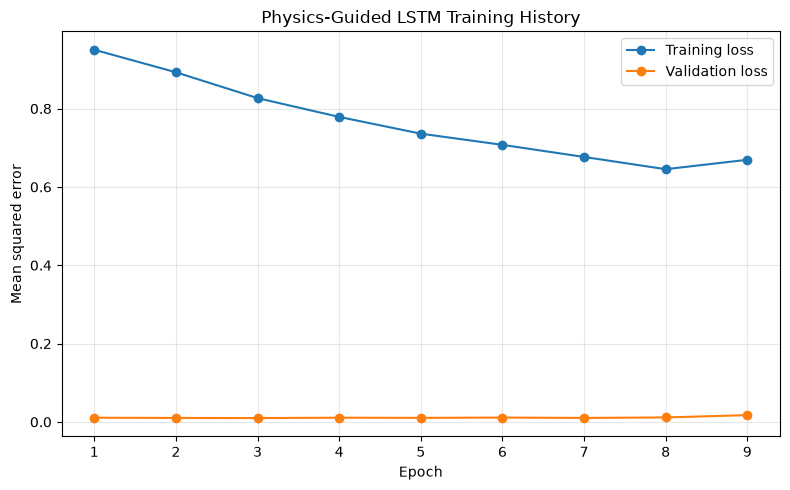

Best epoch: 3
Best validation loss: 0.009767032280150387


In [45]:
# Step 164: Plot training and validation loss

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("Physics-Guided LSTM Training History")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_epoch = val_losses.index(min(val_losses)) + 1

print("Best epoch:", best_epoch)
print("Best validation loss:", min(val_losses))

In [46]:
# Step 165A: Check available scaler names

for name in globals():
    if "scaler" in name.lower():
        print(name, "->", type(globals()[name]).__name__)

StandardScaler -> type
physics_feature_scaler -> StandardScaler
physics_target_scaler -> StandardScaler


In [47]:
# Generate predictions on the final test set

import numpy as np

physics_model.eval()

test_predictions_scaled = []
test_targets_scaled = []

with torch.no_grad():

    for X_batch, y_batch in test_phys_loader:

        X_batch = X_batch.to(device)

        predictions = physics_model(X_batch)

        test_predictions_scaled.append(
            predictions.cpu().numpy()
        )

        test_targets_scaled.append(
            y_batch.numpy()
        )


# Combine all batches
test_predictions_scaled = np.vstack(
    test_predictions_scaled
)

test_targets_scaled = np.vstack(
    test_targets_scaled
)


# Convert back to original soil-moisture-change units
test_predictions_delta = (
    physics_target_scaler.inverse_transform(
        test_predictions_scaled
    )
)

test_targets_delta = (
    physics_target_scaler.inverse_transform(
        test_targets_scaled
    )
)


print("Number of test predictions:",
      len(test_predictions_delta))

print("Prediction shape:",
      test_predictions_delta.shape)

print("Target shape:",
      test_targets_delta.shape)

print("\nPredicted change range:")
print(
    float(test_predictions_delta.min()),
    "to",
    float(test_predictions_delta.max())
)

print("\nObserved change range:")
print(
    float(test_targets_delta.min()),
    "to",
    float(test_targets_delta.max())
)

print("\nFirst 5 predicted changes:")
print(test_predictions_delta[:5].flatten())

print("\nFirst 5 observed changes:")
print(test_targets_delta[:5].flatten())

Number of test predictions: 1948
Prediction shape: (1948, 1)
Target shape: (1948, 1)

Predicted change range:
-0.0014780174242332578 to 0.0002173857792513445

Observed change range:
-0.0020000000949949026 to 0.010999999940395355

First 5 predicted changes:
[-1.6846861e-05 -1.7832925e-05 -1.7249517e-05 -1.6346545e-05
 -1.7863476e-05]

First 5 observed changes:
[0. 0. 0. 0. 0.]


In [48]:
# Evaluate change prediction against persistence

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = test_targets_delta.flatten()
y_pred = test_predictions_delta.flatten()

# Persistence assumes no change over the next hour
y_persistence = np.zeros_like(y_true)

# Physics-guided LSTM
physics_mae = mean_absolute_error(y_true, y_pred)
physics_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
physics_r2 = r2_score(y_true, y_pred)

# Persistence
persistence_mae = mean_absolute_error(y_true, y_persistence)
persistence_rmse = np.sqrt(
    mean_squared_error(y_true, y_persistence)
)
persistence_r2 = r2_score(y_true, y_persistence)

print("FINAL TEST SET")
print("Samples:", len(y_true))

print("\nPersistence")
print("MAE :", persistence_mae)
print("RMSE:", persistence_rmse)
print("R²  :", persistence_r2)

print("\nPhysics-guided LSTM")
print("MAE :", physics_mae)
print("RMSE:", physics_rmse)
print("R²  :", physics_r2)

print("\nDifference relative to persistence")
print(
    "MAE change (%):",
    100 * (physics_mae - persistence_mae)
    / persistence_mae
)
print(
    "RMSE change (%):",
    100 * (physics_rmse - persistence_rmse)
    / persistence_rmse
)

FINAL TEST SET
Samples: 1948

Persistence
MAE : 0.00018737166828941554
RMSE: 0.0007639866585924316
R²  : -0.0006872415542602539

Physics-guided LSTM
MAE : 0.0006523266201838851
RMSE: 0.0010121603569516002
R²  : -0.7564083337783813

Difference relative to persistence
MAE change (%): 248.14581422005435
RMSE change (%): 32.48403562653877


In [49]:
# Evaluate meaningful soil-moisture changes

event_threshold = 0.001

meaningful_mask = np.abs(y_true) >= event_threshold
wetting_mask = y_true >= event_threshold
drying_mask = y_true <= -event_threshold


def evaluate_subset(name, mask):

    true_subset = y_true[mask]
    pred_subset = y_pred[mask]
    persistence_subset = y_persistence[mask]

    print(f"\n{name}")
    print("Samples:", len(true_subset))

    if len(true_subset) == 0:
        return

    persistence_mae = mean_absolute_error(
        true_subset,
        persistence_subset
    )

    physics_mae = mean_absolute_error(
        true_subset,
        pred_subset
    )

    persistence_rmse = np.sqrt(
        mean_squared_error(
            true_subset,
            persistence_subset
        )
    )

    physics_rmse = np.sqrt(
        mean_squared_error(
            true_subset,
            pred_subset
        )
    )

    print(
        "Persistence MAE :",
        persistence_mae
    )

    print(
        "Physics LSTM MAE :",
        physics_mae
    )

    print(
        "Persistence RMSE:",
        persistence_rmse
    )

    print(
        "Physics LSTM RMSE:",
        physics_rmse
    )

    print(
        "MAE change vs persistence (%):",
        100 * (physics_mae - persistence_mae)
        / persistence_mae
    )


print(
    "Meaningful-change threshold:",
    event_threshold
)

print(
    "Meaningful events:",
    meaningful_mask.sum()
)

print(
    "Wetting events:",
    wetting_mask.sum()
)

print(
    "Drying events:",
    drying_mask.sum()
)

evaluate_subset(
    "ALL MEANINGFUL CHANGES",
    meaningful_mask
)

evaluate_subset(
    "WETTING EVENTS",
    wetting_mask
)

evaluate_subset(
    "DRYING EVENTS",
    drying_mask
)

Meaningful-change threshold: 0.001
Meaningful events: 270
Wetting events: 108
Drying events: 162

ALL MEANINGFUL CHANGES
Samples: 270
Persistence MAE : 0.0013518519699573517
Physics LSTM MAE : 0.0012430802453309298
Persistence RMSE: 0.002052098945247792
Physics LSTM RMSE: 0.0020847079519080752
MAE change vs persistence (%): -8.046126872149578

WETTING EVENTS
Samples: 108
Persistence MAE : 0.0018703705864027143
Physics LSTM MAE : 0.0022896581795066595
Persistence RMSE: 0.002999999749891372
Physics LSTM RMSE: 0.003206563222021213
MAE change vs persistence (%): 22.417353873724114

DRYING EVENTS
Samples: 162
Persistence MAE : 0.0010061729699373245
Physics LSTM MAE : 0.0005453618359751999
Persistence RMSE: 0.0010092168616533277
Physics LSTM RMSE: 0.0006234155311032559
MAE change vs persistence (%): -45.79840124216704


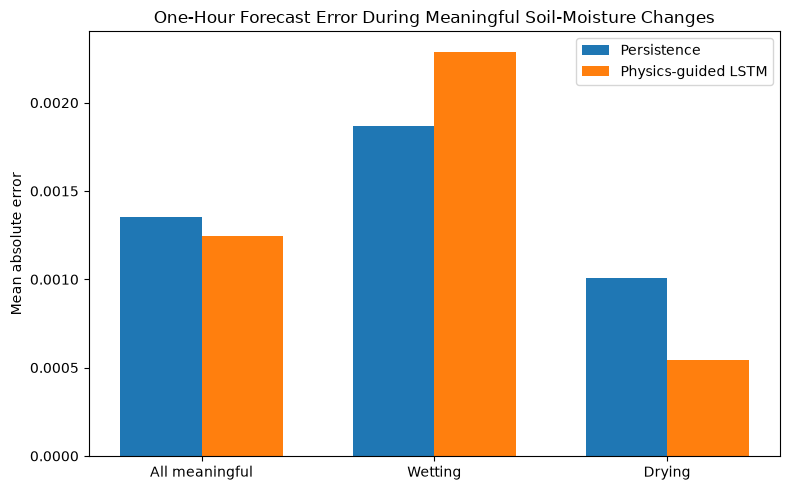

Event comparison

All meaningful: Persistence=0.001352, Physics LSTM=0.001243, Change=-8.05%
Wetting: Persistence=0.001870, Physics LSTM=0.002290, Change=22.42%
Drying: Persistence=0.001006, Physics LSTM=0.000545, Change=-45.80%


In [50]:
# Compare persistence and physics-guided LSTM by event type

event_names = [
    "All meaningful",
    "Wetting",
    "Drying"
]

persistence_event_mae = [
    mean_absolute_error(
        y_true[meaningful_mask],
        y_persistence[meaningful_mask]
    ),
    mean_absolute_error(
        y_true[wetting_mask],
        y_persistence[wetting_mask]
    ),
    mean_absolute_error(
        y_true[drying_mask],
        y_persistence[drying_mask]
    )
]

physics_event_mae = [
    mean_absolute_error(
        y_true[meaningful_mask],
        y_pred[meaningful_mask]
    ),
    mean_absolute_error(
        y_true[wetting_mask],
        y_pred[wetting_mask]
    ),
    mean_absolute_error(
        y_true[drying_mask],
        y_pred[drying_mask]
    )
]

x = np.arange(len(event_names))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    persistence_event_mae,
    width,
    label="Persistence"
)

plt.bar(
    x + width / 2,
    physics_event_mae,
    width,
    label="Physics-guided LSTM"
)

plt.xticks(x, event_names)

plt.ylabel("Mean absolute error")
plt.title(
    "One-Hour Forecast Error During Meaningful Soil-Moisture Changes"
)

plt.legend()
plt.tight_layout()
plt.show()

print("Event comparison")
print()

for name, p_mae, model_mae in zip(
    event_names,
    persistence_event_mae,
    physics_event_mae
):
    change = 100 * (model_mae - p_mae) / p_mae

    print(
        f"{name}: "
        f"Persistence={p_mae:.6f}, "
        f"Physics LSTM={model_mae:.6f}, "
        f"Change={change:.2f}%"
    )

## Physics-guided forecasting findings

The physics-guided LSTM was evaluated on 1,948 unseen test sequences using a one-hour forecasting horizon. The model used recent measurements from the six soil-moisture sensors together with rainfall, irrigation, temperature and previous-hour water-input information.

Across the complete test set, persistence remained the stronger baseline. The physics-guided LSTM produced an MAE of 0.000652 compared with 0.000187 for persistence. This is partly explained by the large number of stable periods in the dataset, where assuming little or no change is difficult to beat.

The behaviour was different during meaningful soil-moisture changes. Using an absolute one-hour change of 0.001 as the event threshold, 270 meaningful events were identified. Across these events, the physics-guided model reduced MAE by about 8.05% relative to persistence.

The largest improvement occurred during drying events. For 162 drying events, MAE decreased from 0.001006 with persistence to 0.000545 with the physics-guided LSTM, an improvement of about 45.8%. RMSE also decreased from 0.001009 to 0.000623.

The model was less successful during wetting events. Across 108 wetting events, its MAE was about 22.4% higher than persistence. The observed one-hour moisture increases reached approximately 0.011, while the largest increase predicted by the model was only about 0.000217. This indicates that the model tends to underestimate larger wetting responses.

These results suggest that the current model captures part of the gradual drying behaviour but does not yet represent abrupt wetting events well. The model should therefore be treated as a physics-guided forecasting prototype rather than a complete physical representation of the irrigation system.

The next stage will investigate robustness and uncertainty, particularly when sensor measurements are noisy or missing.